# Irrigation Need Prediction Model

**Sensor Inputs (IoT):**
- Humidity (DHT11/DHT22)
- Soil Moisture (Capacitive sensor)
- Temperature (DHT11/DHT22)

**Manual Inputs:**
- Crop Type (Wheat, Rice, Cotton, Maize, Sugarcane, Potato)
- Season (Kharif, Rabi, Zaid - Indian agricultural seasons)
- Region (North, South, East, West, Central - India)

In [20]:
import pandas as pd
import numpy as np 
import joblib
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns 
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("irrigation_prediction.csv")
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [22]:
print("Unique Irrigation Need values:", df["Irrigation_Need"].unique())
print("\nTarget distribution:")
print(df["Irrigation_Need"].value_counts())
print("\nDataset shape:", df.shape)
df.info()

Unique Irrigation Need values: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Target distribution:
Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64

Dataset shape: (10000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  str    
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type           

## Data Preprocessing

In [23]:
df["Irrigation_Needed"] = df["Irrigation_Need"].apply(lambda x: 0 if x == "Low" else 1)
print("Binary target distribution:")
print(df["Irrigation_Needed"].value_counts())
print(f"\nClass ratio: {df['Irrigation_Needed'].value_counts()[1] / df['Irrigation_Needed'].value_counts()[0]:.2f}")

Binary target distribution:
Irrigation_Needed
0    5864
1    4136
Name: count, dtype: int64

Class ratio: 0.71


In [24]:
sensor_columns = ["Humidity", "Soil_Moisture", "Temperature_C"]
manual_columns = ["Crop_Type", "Season", "Region"]

df_cleaned = df[sensor_columns + manual_columns + ["Irrigation_Needed"]].copy()
df_cleaned.head()

,Humidity,Soil_Moisture,Temperature_C,Crop_Type,Season,Region,Irrigation_Needed
0,31.19,36.48,21.90,Wheat,Rabi,South,0
1,26.01,50.56,36.50,Maize,Zaid,Central,1
2,76.41,40.07,41.83,Cotton,Rabi,South,0
3,43.32,12.75,37.22,Wheat,Kharif,North,1
4,86.44,18.58,22.38,Cotton,Zaid,South,1


In [25]:
print("Missing values:")
print(df_cleaned.isna().sum())
print("\nData types:")
print(df_cleaned.dtypes)

Missing values:
Humidity             0
Soil_Moisture        0
Temperature_C        0
Crop_Type            0
Season               0
Region               0
Irrigation_Needed    0
dtype: int64

Data types:
Humidity             float64
Soil_Moisture        float64
Temperature_C        float64
Crop_Type                str
Season                   str
Region                   str
Irrigation_Needed      int64
dtype: object


In [26]:
ohe_crop = OneHotEncoder(sparse_output=False)
crop_encoded = ohe_crop.fit_transform(df_cleaned[["Crop_Type"]])
crop_df = pd.DataFrame(crop_encoded, columns=ohe_crop.get_feature_names_out(['Crop_Type']), index=df_cleaned.index)

joblib.dump(ohe_crop, "irrigation_crop_encoder.pkl")
print("Crop type categories:", ohe_crop.categories_[0])
crop_df.head()

Crop type categories: ['Cotton' 'Maize' 'Potato' 'Rice' 'Sugarcane' 'Wheat']


,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Potato,Crop_Type_Rice,Crop_Type_Sugarcane,Crop_Type_Wheat
0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0,0.0


In [27]:
le_season = LabelEncoder()
le_region = LabelEncoder()

df_cleaned["Season_encoded"] = le_season.fit_transform(df_cleaned["Season"])
df_cleaned["Region_encoded"] = le_region.fit_transform(df_cleaned["Region"])

joblib.dump(le_season, "irrigation_season_encoder.pkl")
joblib.dump(le_region, "irrigation_region_encoder.pkl")

print("Season mapping:", dict(zip(le_season.classes_, range(len(le_season.classes_)))))
print("Region mapping:", dict(zip(le_region.classes_, range(len(le_region.classes_)))))

Season mapping: {'Kharif': 0, 'Rabi': 1, 'Zaid': 2}
Region mapping: {'Central': 0, 'East': 1, 'North': 2, 'South': 3, 'West': 4}


In [28]:
df_final = pd.concat([
    df_cleaned[sensor_columns],
    crop_df,
    df_cleaned[["Season_encoded", "Region_encoded"]],
    df_cleaned[["Irrigation_Needed"]]
], axis=1)

df_final.head()

,Humidity,Soil_Moisture,Temperature_C,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Potato,Crop_Type_Rice,Crop_Type_Sugarcane,Crop_Type_Wheat,Season_encoded,Region_encoded,Irrigation_Needed
0,31.19,36.48,21.90,0.0,0.0,0.0,0.0,0.0,1.0,1,3,0
1,26.01,50.56,36.50,0.0,1.0,0.0,0.0,0.0,0.0,2,0,1
2,76.41,40.07,41.83,1.0,0.0,0.0,0.0,0.0,0.0,1,3,0
3,43.32,12.75,37.22,0.0,0.0,0.0,0.0,0.0,1.0,0,2,1
4,86.44,18.58,22.38,1.0,0.0,0.0,0.0,0.0,0.0,2,3,1


In [29]:
df_final["temp_humidity"] = df_final["Temperature_C"] * df_final["Humidity"]
df_final["temp_moisture"] = df_final["Temperature_C"] * df_final["Soil_Moisture"]

print("Final dataset shape:", df_final.shape)
df_final.head()

Final dataset shape: (10000, 14)


,Humidity,Soil_Moisture,Temperature_C,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Potato,Crop_Type_Rice,Crop_Type_Sugarcane,Crop_Type_Wheat,Season_encoded,Region_encoded,Irrigation_Needed,temp_humidity,temp_moisture
0,31.19,36.48,21.90,0.0,0.0,0.0,0.0,0.0,1.0,1,3,0,683.0610,798.9120
1,26.01,50.56,36.50,0.0,1.0,0.0,0.0,0.0,0.0,2,0,1,949.3650,1845.4400
2,76.41,40.07,41.83,1.0,0.0,0.0,0.0,0.0,0.0,1,3,0,3196.2303,1676.1281
3,43.32,12.75,37.22,0.0,0.0,0.0,0.0,0.0,1.0,0,2,1,1612.3704,474.5550
4,86.44,18.58,22.38,1.0,0.0,0.0,0.0,0.0,0.0,2,3,1,1934.5272,415.8204


In [30]:
print("Correlation with Irrigation_Needed:")
print(df_final.corr()['Irrigation_Needed'].sort_values(ascending=False))

Correlation with Irrigation_Needed:
Irrigation_Needed      1.000000
Temperature_C          0.199082
temp_humidity          0.141738
Crop_Type_Potato       0.011552
Crop_Type_Maize        0.009398
Humidity               0.006603
Crop_Type_Cotton       0.004053
Region_encoded         0.000503
Crop_Type_Sugarcane   -0.001641
Season_encoded        -0.004180
Crop_Type_Wheat       -0.008822
Crop_Type_Rice        -0.014380
temp_moisture         -0.158243
Soil_Moisture         -0.344620
Name: Irrigation_Needed, dtype: float64


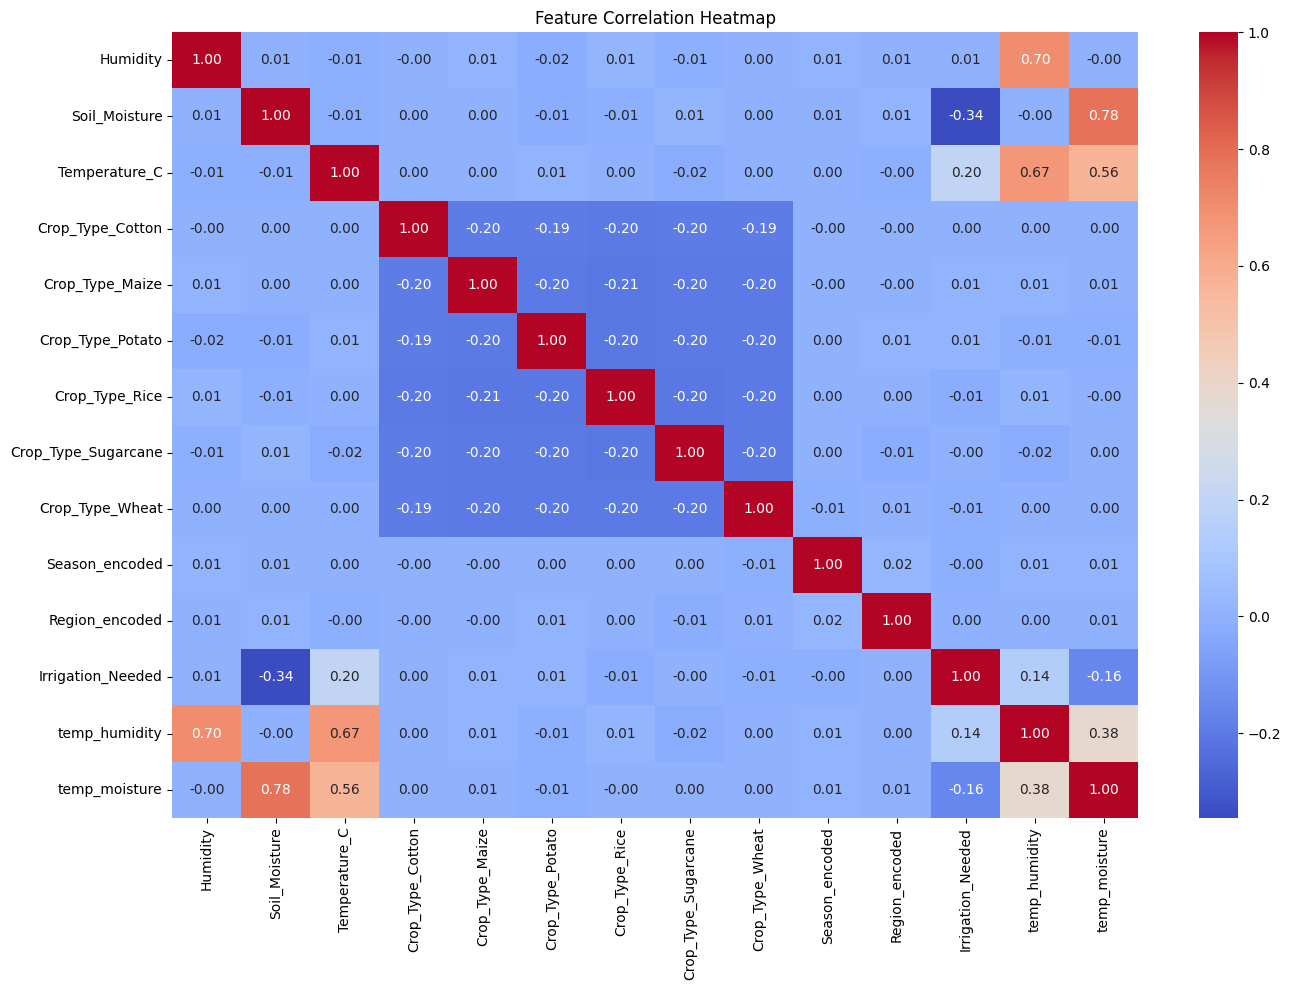

In [31]:
plt.figure(figsize=(14, 10))
sns.heatmap(df_final.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Model Training

In [32]:
X = df_final.drop(columns=["Irrigation_Needed"])
y = df_final["Irrigation_Needed"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")

Training set size: 8000
Test set size: 2000

Training set class distribution:
Irrigation_Needed
0    4691
1    3309
Name: count, dtype: int64

Test set class distribution:
Irrigation_Needed
0    1173
1     827
Name: count, dtype: int64


In [33]:
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)

print("=== RANDOM FOREST RESULTS ===")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Irrigation Needed", "Irrigation Needed"]))

=== RANDOM FOREST RESULTS ===

Accuracy: 0.7160

Classification Report:
                      precision    recall  f1-score   support

No Irrigation Needed       0.72      0.85      0.78      1173
   Irrigation Needed       0.71      0.52      0.60       827

            accuracy                           0.72      2000
           macro avg       0.72      0.69      0.69      2000
        weighted avg       0.72      0.72      0.71      2000



In [34]:
from xgboost import XGBClassifier

xgb_classifier = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_test)

print("=== XGBoost RESULTS ===")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=["No Irrigation Needed", "Irrigation Needed"]))

=== XGBoost RESULTS ===

Accuracy: 0.7065

Classification Report:
                      precision    recall  f1-score   support

No Irrigation Needed       0.72      0.83      0.77      1173
   Irrigation Needed       0.69      0.54      0.60       827

            accuracy                           0.71      2000
           macro avg       0.70      0.68      0.68      2000
        weighted avg       0.70      0.71      0.70      2000



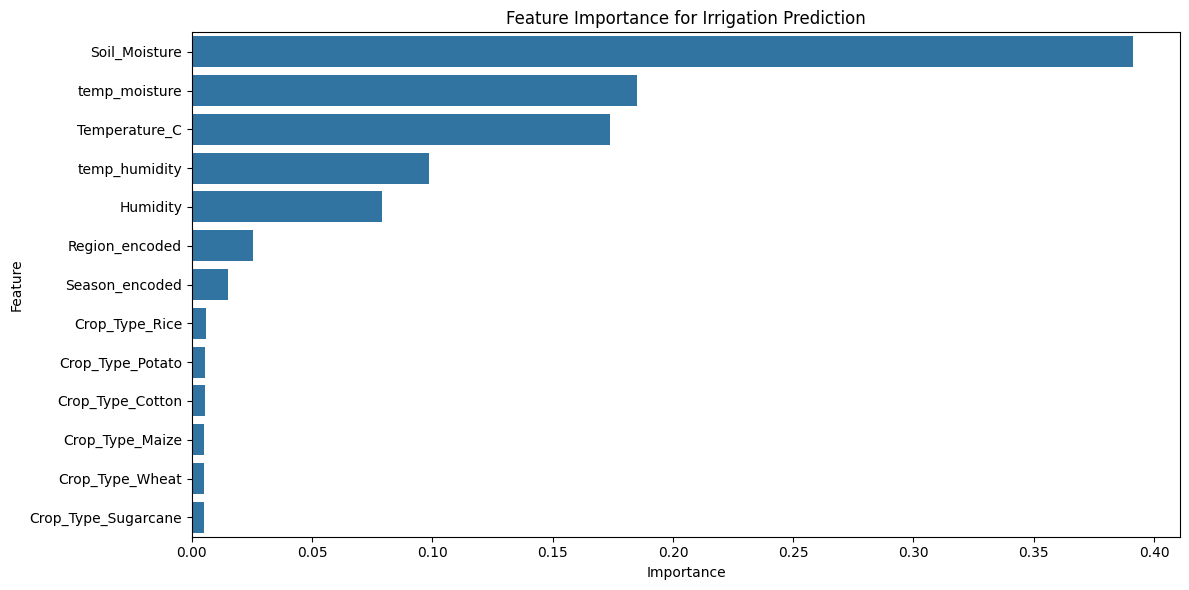

Top 10 most important features:
             feature  importance
1      Soil_Moisture    0.391240
12     temp_moisture    0.184966
2      Temperature_C    0.173995
11     temp_humidity    0.098399
0           Humidity    0.078881
10    Region_encoded    0.025360
9     Season_encoded    0.014911
6     Crop_Type_Rice    0.006041
5   Crop_Type_Potato    0.005639
3   Crop_Type_Cotton    0.005498


In [35]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title("Feature Importance for Irrigation Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(feature_importance.head(10))

In [36]:
joblib.dump(rf_classifier, "irrigation_model.pkl")
joblib.dump(list(X.columns), "irrigation_feature_names.pkl")

print("Model saved as 'irrigation_model.pkl'")
print("Feature names saved as 'irrigation_feature_names.pkl'")
print("Encoders: 'irrigation_crop_encoder.pkl', 'irrigation_season_encoder.pkl', 'irrigation_region_encoder.pkl'")

Model saved as 'irrigation_model.pkl'
Feature names saved as 'irrigation_feature_names.pkl'
Encoders: 'irrigation_crop_encoder.pkl', 'irrigation_season_encoder.pkl', 'irrigation_region_encoder.pkl'


## Prediction Function

In [37]:
def predict_irrigation(humidity, soil_moisture, temperature, crop_type, season, region):
    """
    Predict if irrigation is needed based on sensor data and manual inputs.
    
    Sensor Inputs:
    - humidity: float (DHT11/DHT22 sensor)
    - soil_moisture: float (Capacitive moisture sensor)
    - temperature: float (DHT11/DHT22 sensor, in Celsius)
    
    Manual Inputs:
    - crop_type: str ('Wheat', 'Rice', 'Cotton', 'Maize', 'Sugarcane', 'Potato')
    - season: str ('Kharif', 'Rabi', 'Zaid')
    - region: str ('North', 'South', 'East', 'West', 'Central' - India)
    
    Returns:
    - prediction: int (0 = No irrigation needed, 1 = Irrigation needed)
    - probability: float (probability of irrigation being needed)
    """
    model = joblib.load("irrigation_model.pkl")
    crop_encoder = joblib.load("irrigation_crop_encoder.pkl")
    season_encoder = joblib.load("irrigation_season_encoder.pkl")
    region_encoder = joblib.load("irrigation_region_encoder.pkl")
    feature_names = joblib.load("irrigation_feature_names.pkl")
    
    crop_encoded = crop_encoder.transform([[crop_type]])
    crop_cols = crop_encoder.get_feature_names_out(['Crop_Type'])
    
    season_encoded = season_encoder.transform([season])
    region_encoded = region_encoder.transform([region])
    
    temp_humidity = temperature * humidity
    temp_moisture = temperature * soil_moisture
    
    input_data = {
        'Humidity': humidity,
        'Soil_Moisture': soil_moisture,
        'Temperature_C': temperature,
        'Season_encoded': season_encoded[0],
        'Region_encoded': region_encoded[0],
        'temp_humidity': temp_humidity,
        'temp_moisture': temp_moisture
    }
    
    for i, col in enumerate(crop_cols):
        input_data[col] = crop_encoded[0][i]
    
    input_df = pd.DataFrame([input_data])[feature_names]
    
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]
    
    return prediction, probability

In [38]:
humidity = 65.0
soil_moisture = 25.0
temperature = 32.5

crop_type = "Wheat"
season = "Rabi"
region = "North"

prediction, probability = predict_irrigation(
    humidity=humidity,
    soil_moisture=soil_moisture,
    temperature=temperature,
    crop_type=crop_type,
    season=season,
    region=region
)

print("=== IRRIGATION PREDICTION ===")
print(f"\nSensor Data:")
print(f"  - Humidity: {humidity}%")
print(f"  - Soil Moisture: {soil_moisture}%")
print(f"  - Temperature: {temperature}°C")
print(f"\nManual Inputs:")
print(f"  - Crop Type: {crop_type}")
print(f"  - Season: {season}")
print(f"  - Region: {region} India")
print(f"\nResult: {'IRRIGATION NEEDED' if prediction == 1 else 'NO IRRIGATION NEEDED'}")
print(f"Confidence: {probability * 100:.2f}%")

=== IRRIGATION PREDICTION ===

Sensor Data:
  - Humidity: 65.0%
  - Soil Moisture: 25.0%
  - Temperature: 32.5°C

Manual Inputs:
  - Crop Type: Wheat
  - Season: Rabi
  - Region: North India

Result: IRRIGATION NEEDED
Confidence: 66.45%


d:\mini project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
